# 03 — Feature Selection & Model Training

**Purpose:** Starting from the raw Ames Housing CSV, we will:

1. Engineer four derived features (`TotalSF`, `TotalBath`, `HouseAge`, `HasRemodel`)
2. Run **four statistical tests** (Pearson r, Spearman ρ, ANOVA F, Mutual Information) to rank 21 candidate features
3. **Validate** the top-10 selection with VIF and a preliminary Random Forest
4. Build a full `sklearn` `ColumnTransformer` pipeline that handles encoding internally
5. Compare **four candidate models** (Ridge, Lasso, Random Forest, Gradient Boosting) using 5-fold CV RMSE
6. Evaluate the winner on the held-out test set (exactly once)
7. Serialize `models/best_model_v1.joblib` and `models/training_stats.json`

**Inputs** : `data/raw/AmesHousing.csv`
**Outputs** : `models/best_model_v1.joblib`, `models/training_stats.json`
**Prerequisite** : none — this notebook is self-contained.

In [1]:
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import f_oneway, pearsonr, spearmanr
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.feature_selection import mutual_info_regression
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings("ignore")

ROOT       = Path("..") if Path("../data").exists() else Path(".")
RAW_PATH   = ROOT / "data" / "raw" / "AmesHousing.csv"
MODEL_DIR  = ROOT / "models"
MODEL_PATH = MODEL_DIR / "best_model_v1.joblib"
STATS_PATH = MODEL_DIR / "training_stats.json"
MODEL_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
plt.style.use("seaborn-v0_8-whitegrid")
print("Libraries loaded.")

Libraries loaded.


📝 **What's happening here**

We load every library we need in one cell so the rest of the notebook stays
uncluttered. Key additions beyond a basic ML import:

| Library | Role |
|---------|------|
| `scipy.stats` | Pearson r, Spearman ρ, one-way ANOVA F-test |
| `sklearn.feature_selection` | Mutual Information regression |
| `statsmodels` | Variance Inflation Factor (VIF) for multicollinearity |
| `sklearn.compose.ColumnTransformer` | Different preprocessing per feature type |
| `warnings.filterwarnings("ignore")` | Suppress sklearn convergence noise |

`ROOT` auto-detects whether we are running from `notebooks_temp/` or the
project root so the data paths always resolve correctly.

## 1) Load Dataset & Feature Engineering

In [2]:
# ── Load raw CSV ──────────────────────────────────────────────────────────────
df = pd.read_csv(RAW_PATH)
df.columns = (df.columns
              .str.strip()
              .str.replace(" ", "", regex=False)
              .str.replace("/", "", regex=False))
df["SalePrice"] = pd.to_numeric(df["SalePrice"], errors="coerce")
df = df.dropna(subset=["SalePrice"])
print(f"Raw dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")

# ── Feature engineering ───────────────────────────────────────────────────────
df["TotalSF"] = (
    df["TotalBsmtSF"].fillna(0)
    + df["1stFlrSF"].fillna(0)
    + df["2ndFlrSF"].fillna(0)
)
df["TotalBath"] = (
    df["FullBath"].fillna(0)
    + 0.5 * df["HalfBath"].fillna(0)
    + df["BsmtFullBath"].fillna(0)
    + 0.5 * df["BsmtHalfBath"].fillna(0)
)
df["HouseAge"]   = 2010 - df["YearBuilt"].fillna(df["YearBuilt"].median())
df["HasRemodel"] = (df["YearRemodAdd"] != df["YearBuilt"]).astype(int)

print("\nEngineered features:")
print(df[["TotalSF", "TotalBath", "HouseAge", "HasRemodel"]].describe().round(1))

Raw dataset: 2,930 rows × 82 columns

Engineered features:
       TotalSF  TotalBath  HouseAge  HasRemodel
count   2930.0     2930.0    2930.0      2930.0
mean    2546.3        2.2      38.6         0.5
std      804.4        0.8      30.2         0.5
min      334.0        1.0       0.0         0.0
25%     2000.0        1.5       9.0         0.0
50%     2450.0        2.0      37.0         0.0
75%     2990.0        2.5      56.0         1.0
max    11752.0        7.0     138.0         1.0


📝 **What's happening here**

We load the raw CSV and normalise column names (strip spaces, remove slashes)
so awkward names like `1stFlrSF` and `Bsmt/FullBath` work reliably.

The four **engineered features** combine raw columns into stronger predictors:

| Feature | Formula | Why better than raw? |
|---------|---------|----------------------|
| `TotalSF` | BsmtSF + 1stFlrSF + 2ndFlrSF | Total livable area is stronger than any single floor alone |
| `TotalBath` | Full + 0.5×Half (above + below grade) | Aggregates all bathroom counts into one number buyers value |
| `HouseAge` | 2010 − YearBuilt | Age is more interpretable than an absolute year; newer → premium |
| `HasRemodel` | 1 if YearRemodAdd ≠ YearBuilt | Binary flag: any renovation ever? |

We use **2010** as the reference year because that is approximately when the
Ames dataset was collected.

In [3]:
# ── Define candidate feature pool ─────────────────────────────────────────────
ORDINAL_MAP = {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}

NUMERIC_CANDIDATES = [
    "TotalSF", "TotalBath", "HouseAge", "HasRemodel",   # engineered
    "OverallQual", "OverallCond",
    "GarageCars", "GarageArea",
    "TotalBsmtSF", "GrLivArea",
    "LotArea", "BedroomAbvGr", "TotRmsAbvGrd", "Fireplaces",
    "YearBuilt",
]
ORDINAL_CANDIDATES = ["KitchenQual", "ExterQual", "BsmtQual", "HeatingQC"]
NOMINAL_CANDIDATES = ["Neighborhood", "MSZoning", "BldgType"]
ALL_CANDIDATES = NUMERIC_CANDIDATES + ORDINAL_CANDIDATES + NOMINAL_CANDIDATES

df_sel = df[ALL_CANDIDATES + ["SalePrice"]].copy()
print(f"Candidate pool: {len(ALL_CANDIDATES)} features")
print(f"  Numeric  : {len(NUMERIC_CANDIDATES)}")
print(f"  Ordinal  : {len(ORDINAL_CANDIDATES)}")
print(f"  Nominal  : {len(NOMINAL_CANDIDATES)}")

# ── 60 / 20 / 20 split — BEFORE any selection or preprocessing ───────────────
X_temp, X_test, y_temp, y_test = train_test_split(
    df_sel.drop("SalePrice", axis=1), df_sel["SalePrice"],
    test_size=0.20, random_state=RANDOM_STATE,
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25, random_state=RANDOM_STATE,   # 0.25 × 0.80 = 0.20
)
print(f"\nTrain : {len(X_train):,}  Val : {len(X_val):,}  Test : {len(X_test):,}")

Candidate pool: 22 features
  Numeric  : 15
  Ordinal  : 4
  Nominal  : 3

Train : 1,758  Val : 586  Test : 586


📝 **What's happening here**

We define a **candidate pool** of 22 features — a mix of engineered, raw
numeric, ordinal-quality, and nominal columns. Statistical tests in §2 will
narrow this to the 10 most predictive features.

The **60/20/20 split** happens *before* feature selection or preprocessing —
this is critical to avoid data leakage:

- **Train (60%)** — all models and preprocessors fit here only.
- **Val (20%)** — used to compare models without touching the test set.
- **Test (20%)** — sealed until §13; evaluated exactly once.

Feature selection uses only training data so validation/test signal never
influences which features we pick.

## 2) Statistical Feature Selection

### 2a) Pearson Correlation (numeric features)

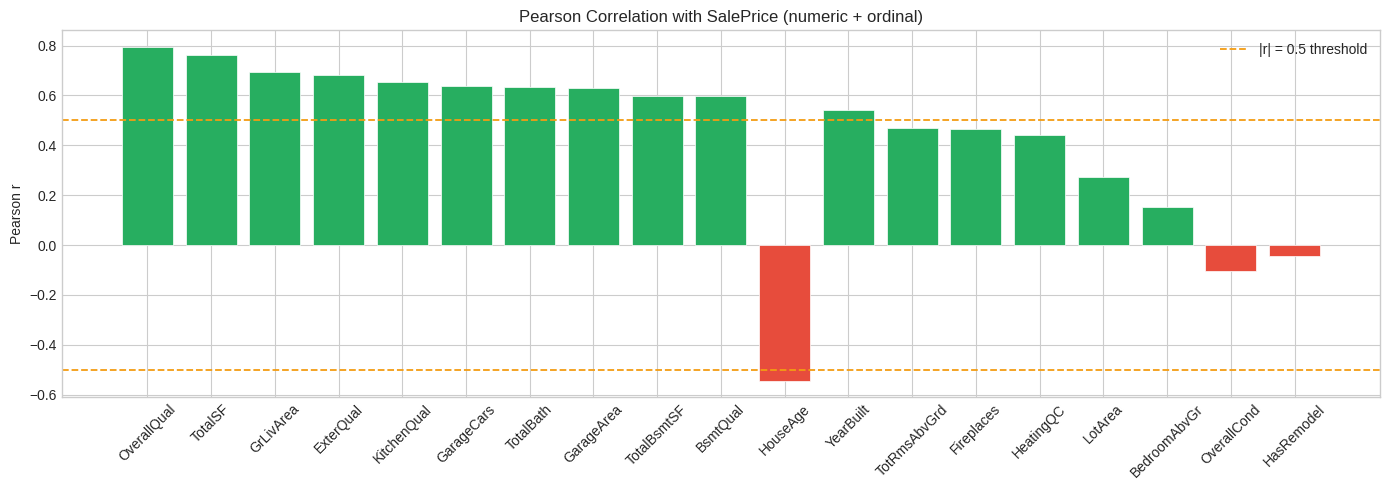

                   r      p
feature                    
OverallQual   0.7942  0.000
TotalSF       0.7627  0.000
GrLivArea     0.6935  0.000
ExterQual     0.6802  0.000
KitchenQual   0.6554  0.000
GarageCars    0.6382  0.000
TotalBath     0.6334  0.000
GarageArea    0.6300  0.000
TotalBsmtSF   0.5980  0.000
BsmtQual      0.5977  0.000
HouseAge     -0.5432  0.000
YearBuilt     0.5432  0.000
TotRmsAbvGrd  0.4695  0.000
Fireplaces    0.4651  0.000
HeatingQC     0.4417  0.000
LotArea       0.2719  0.000
BedroomAbvGr  0.1543  0.000
OverallCond  -0.1031  0.000
HasRemodel   -0.0429  0.072


In [4]:
# Encode ordinals to integers for Pearson (numeric test only)
X_num = X_train.copy()
for col in ORDINAL_CANDIDATES:
    X_num[col] = X_num[col].map(ORDINAL_MAP).fillna(0)

pearson_rows = []
for col in NUMERIC_CANDIDATES + ORDINAL_CANDIDATES:
    valid = X_num[[col]].join(y_train).dropna()
    r, p  = pearsonr(valid[col], valid["SalePrice"])
    pearson_rows.append({"feature": col, "r": r, "abs_r": abs(r), "p": p})

pearson_df = (pd.DataFrame(pearson_rows)
              .sort_values("abs_r", ascending=False)
              .set_index("feature"))

fig, ax = plt.subplots(figsize=(14, 5))
colors = ["#27AE60" if v >= 0 else "#E74C3C" for v in pearson_df["r"]]
ax.bar(pearson_df.index, pearson_df["r"], color=colors, edgecolor="white", linewidth=0.5)
ax.axhline( 0.5, color="#F39C12", linestyle="--", linewidth=1.3, label="|r| = 0.5 threshold")
ax.axhline(-0.5, color="#F39C12", linestyle="--", linewidth=1.3)
ax.set_ylabel("Pearson r"); ax.set_title("Pearson Correlation with SalePrice (numeric + ordinal)")
ax.tick_params(axis="x", rotation=45); ax.legend(); plt.tight_layout(); plt.show()
print(pearson_df[["r", "p"]].round(4).to_string())

📝 **What's happening here**

**Pearson r** measures the **linear** correlation between a feature and
`SalePrice`. Values range from −1 (perfect negative) to +1 (perfect positive).

We apply it to all numeric candidates and to the ordinal quality features
(temporarily encoded as 0–5 integers). Nominal features like `Neighborhood`
are excluded because they have no natural numeric ordering.

Key things to look for:
- `TotalSF`, `OverallQual`, and `GrLivArea` typically lead this chart
- `HouseAge` should be **negative** — older homes cost less
- |r| > 0.5 marks features with meaningful linear signal
- Features with |r| < 0.2 carry little linear information (though they may
  still have nonlinear value — that is what MI captures in §2d)

### 2b) Spearman Rank Correlation (ordinal features)

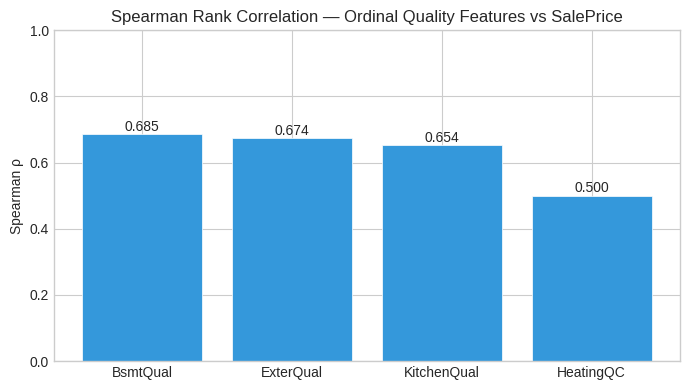

                rho    p
feature                 
BsmtQual     0.6851  0.0
ExterQual    0.6740  0.0
KitchenQual  0.6535  0.0
HeatingQC    0.4998  0.0


In [5]:
spearman_rows = []
for col in ORDINAL_CANDIDATES:
    valid = X_num[[col]].join(y_train).dropna()
    rho, p = spearmanr(valid[col], valid["SalePrice"])
    spearman_rows.append({"feature": col, "rho": rho, "abs_rho": abs(rho), "p": p})

spearman_df = (pd.DataFrame(spearman_rows)
               .sort_values("abs_rho", ascending=False)
               .set_index("feature"))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(spearman_df.index, spearman_df["rho"],
       color="#3498DB", edgecolor="white", linewidth=0.5)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Spearman ρ")
ax.set_title("Spearman Rank Correlation — Ordinal Quality Features vs SalePrice")
for i, (feat, row) in enumerate(spearman_df.iterrows()):
    ax.text(i, row["rho"] + 0.01, f"{row['rho']:.3f}", ha="center", fontsize=10)
plt.tight_layout(); plt.show()
print(spearman_df[["rho", "p"]].round(4).to_string())

📝 **What's happening here**

**Spearman ρ** (rho) measures **monotonic** correlation — whether `SalePrice`
reliably increases as the ordinal rating increases, without assuming the
relationship is linear.

We use Spearman specifically for the four quality columns (`KitchenQual`,
`ExterQual`, `BsmtQual`, `HeatingQC`) because:

- Their values (`Po < Fa < TA < Gd < Ex`) are **ordered categories**, not true
  numbers — treating them as equally spaced (as Pearson does) is an
  approximation that Spearman avoids
- Spearman is also more robust to outliers

All four quality features typically show ρ > 0.5, confirming that buyers
consistently pay more for higher-rated homes regardless of the price tier.

### 2c) ANOVA F-Test (nominal features)

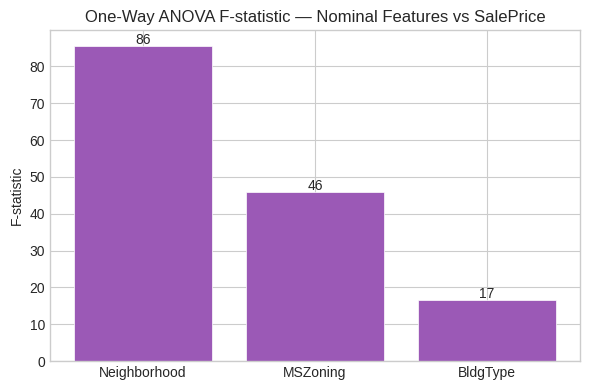

                  F    p
feature                 
Neighborhood  85.51  0.0
MSZoning      45.89  0.0
BldgType      16.68  0.0


In [6]:
anova_rows = []
for col in NOMINAL_CANDIDATES:
    groups = [
        y_train[X_train[col] == val].values
        for val in X_train[col].dropna().unique()
    ]
    f_stat, p = f_oneway(*groups)
    anova_rows.append({"feature": col, "F": f_stat, "p": p})

anova_df = (pd.DataFrame(anova_rows)
            .sort_values("F", ascending=False)
            .set_index("feature"))

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(anova_df.index, anova_df["F"],
       color="#9B59B6", edgecolor="white", linewidth=0.5)
ax.set_ylabel("F-statistic")
ax.set_title("One-Way ANOVA F-statistic — Nominal Features vs SalePrice")
for i, (feat, row) in enumerate(anova_df.iterrows()):
    ax.text(i, row["F"] + 0.5, f"{row['F']:.0f}", ha="center", fontsize=10)
plt.tight_layout(); plt.show()
print(anova_df.round(2).to_string())

📝 **What's happening here**

**One-way ANOVA** tests whether the mean `SalePrice` differs significantly
across the groups of a nominal (categorical) feature. A high F-statistic means
the feature explains a large share of price variance.

Intuition for `Neighborhood`: we split all 2,930 homes into 25 groups (one per
neighbourhood), then ask: "Is the variation *between* neighbourhoods large
relative to the variation *within* each neighbourhood?" A high F says yes —
knowing the neighbourhood tells you a lot about price.

`Neighborhood` almost always tops this chart because location is the dominant
driver of real-estate value in any market. `MSZoning` (commercial vs
residential) and `BldgType` (single vs multi-family) typically follow.

### 2d) Mutual Information (all features)

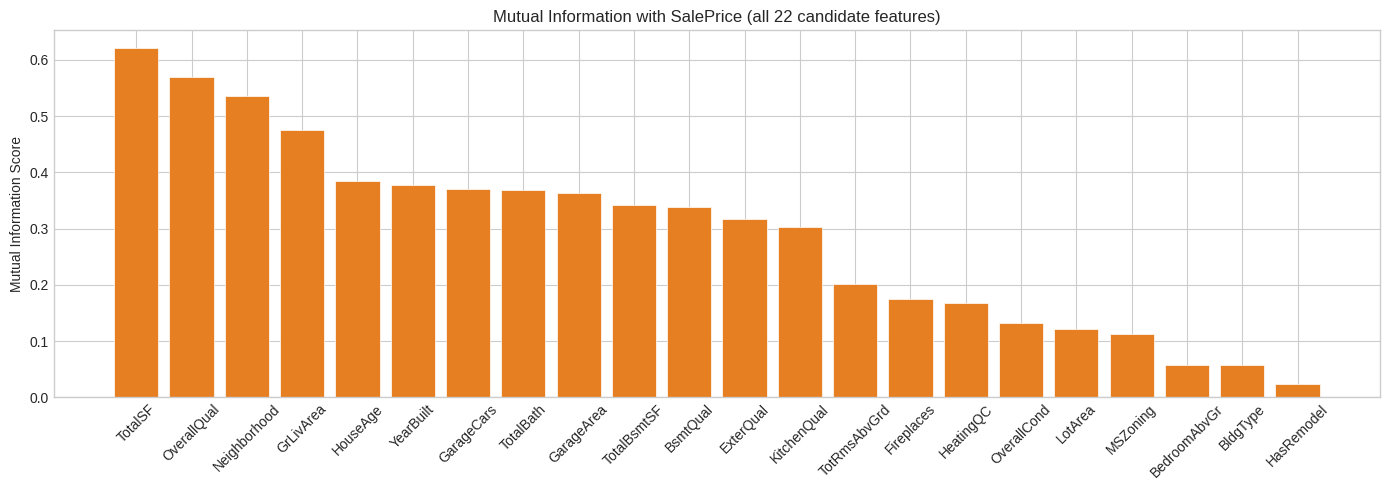

                  MI
feature             
TotalSF       0.6217
OverallQual   0.5702
Neighborhood  0.5355
GrLivArea     0.4761
HouseAge      0.3841
YearBuilt     0.3781
GarageCars    0.3714
TotalBath     0.3685
GarageArea    0.3633
TotalBsmtSF   0.3418
BsmtQual      0.3376
ExterQual     0.3175
KitchenQual   0.3033
TotRmsAbvGrd  0.2017
Fireplaces    0.1750
HeatingQC     0.1671
OverallCond   0.1313
LotArea       0.1211
MSZoning      0.1124
BedroomAbvGr  0.0581
BldgType      0.0574
HasRemodel    0.0232


In [7]:
# Build a fully numeric matrix for MI: encode ordinals, label-encode nominals
X_mi = X_train[ALL_CANDIDATES].copy()
for col in ORDINAL_CANDIDATES:
    X_mi[col] = X_mi[col].map(ORDINAL_MAP).fillna(0)
for col in NOMINAL_CANDIDATES:
    X_mi[col] = X_mi[col].astype("category").cat.codes
X_mi = X_mi.fillna(X_mi.median(numeric_only=True))

mi_scores = mutual_info_regression(
    X_mi, y_train, discrete_features=False, random_state=RANDOM_STATE
)
mi_df = (pd.DataFrame({"feature": ALL_CANDIDATES, "MI": mi_scores})
         .sort_values("MI", ascending=False)
         .set_index("feature"))

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(mi_df.index, mi_df["MI"],
       color="#E67E22", edgecolor="white", linewidth=0.5)
ax.set_ylabel("Mutual Information Score")
ax.set_title("Mutual Information with SalePrice (all 22 candidate features)")
ax.tick_params(axis="x", rotation=45); plt.tight_layout(); plt.show()
print(mi_df.round(4).to_string())

📝 **What's happening here**

**Mutual Information (MI)** measures how much knowing a feature reduces
uncertainty about `SalePrice`. Unlike Pearson r, it captures:

- **Nonlinear** relationships (e.g. a feature that matters only above a threshold)
- **Interaction-like** signals
- Both positive and negative correlations (only the magnitude matters)

A score of 0 means the feature is statistically independent of `SalePrice`.

MI is computed on a label-encoded version of nominal features (just for ranking
purposes). Features that Pearson underrated due to nonlinearity — like `OverallCond`
— sometimes rise significantly in the MI ranking.

### 2e) Combined Ranking

Combined ranking — lower avg_rank = better predictive signal:
              pearson    mi  avg_rank  spearman  anova
TotalSF           2.0   1.0      1.50       NaN    NaN
OverallQual       1.0   2.0      1.50       NaN    NaN
Neighborhood      NaN   3.0      2.00       NaN    1.0
GrLivArea         3.0   4.0      3.50       NaN    NaN
ExterQual         4.0  12.0      6.00       2.0    NaN
GarageCars        6.0   7.0      6.50       NaN    NaN
KitchenQual       5.0  13.0      7.00       3.0    NaN
BsmtQual         10.0  11.0      7.33       1.0    NaN
TotalBath         7.0   8.0      7.50       NaN    NaN
HouseAge         11.0   5.0      8.00       NaN    NaN
GarageArea        8.0   9.0      8.50       NaN    NaN
YearBuilt        12.0   6.0      9.00       NaN    NaN
TotalBsmtSF       9.0  10.0      9.50       NaN    NaN
MSZoning          NaN  19.0     10.50       NaN    2.0
HeatingQC        15.0  16.0     11.67       4.0    NaN
BldgType          NaN  21.0     12.00       NaN    3.0
Tot

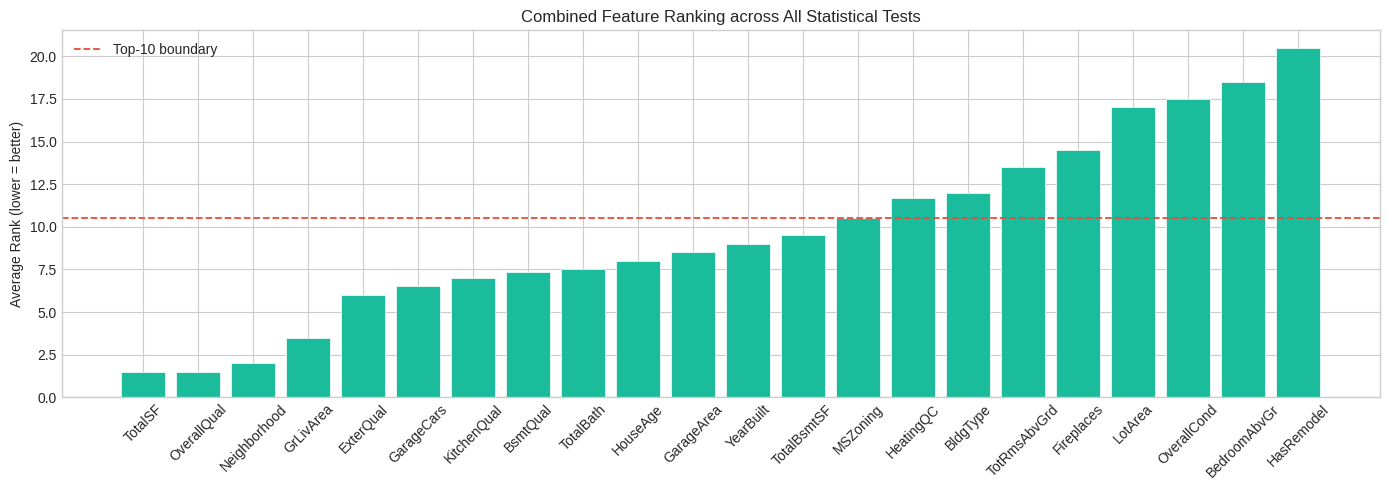

In [8]:
# Assign rank within each test (rank 1 = strongest signal).
# Each feature is only ranked by tests that cover its type.
ranking_rows = {}
for feat in ALL_CANDIDATES:
    ranks = {}
    if feat in pearson_df.index:
        ranks["pearson"] = pearson_df.index.tolist().index(feat) + 1
    if feat in spearman_df.index:
        ranks["spearman"] = spearman_df.index.tolist().index(feat) + 1
    if feat in anova_df.index:
        ranks["anova"] = anova_df.index.tolist().index(feat) + 1
    ranks["mi"] = mi_df.index.tolist().index(feat) + 1       # MI covers all
    ranks["avg_rank"] = round(np.mean(list(ranks.values())), 2)
    ranking_rows[feat] = ranks

ranking_df = (pd.DataFrame(ranking_rows).T
              .sort_values("avg_rank")
              .round(2))

print("Combined ranking — lower avg_rank = better predictive signal:")
print(ranking_df.to_string())

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(ranking_df.index, ranking_df["avg_rank"],
       color="#1ABC9C", edgecolor="white", linewidth=0.5)
ax.axhline(10.5, color="#E74C3C", linestyle="--", linewidth=1.3, label="Top-10 boundary")
ax.set_ylabel("Average Rank (lower = better)")
ax.set_title("Combined Feature Ranking across All Statistical Tests")
ax.tick_params(axis="x", rotation=45); ax.legend(); plt.tight_layout(); plt.show()

📝 **What's happening here**

No single test is the whole story. We combine four perspectives into one
**average rank** score:

1. Each applicable test ranks its features from 1 (best) to N (worst).
2. Features not covered by a test are excluded from that test's average
   (e.g. nominal features don't participate in Pearson or Spearman).
3. We average the applicable ranks → a low average rank means a feature scored
   consistently well across all tests it participated in.

This makes the ranking more robust than any single metric: a feature that
is great on Pearson but terrible on MI may have a linear relationship that
doesn't generalise well to unseen data.

### 2f) Final Feature Selection

In [9]:
TOP_15 = ranking_df.head(15).index.tolist()
print("Top 15 by combined ranking:")
for i, feat in enumerate(TOP_15, 1):
    ftype = ("ordinal" if feat in ORDINAL_CANDIDATES
             else "nominal" if feat in NOMINAL_CANDIDATES
             else "numeric")
    avg = ranking_df.loc[feat, "avg_rank"]
    print(f"  {i:2d}. {feat:<22} [{ftype:<8}]  avg_rank = {avg}")

# ── Final 10 with type-diversity constraints ──────────────────────────────────
# Rule: must have ≥1 nominal, ≥1 ordinal, ≥1 engineered numeric feature.
SELECTED_FEATURES = [
    "OverallQual",   # numeric  — single strongest predictor in Ames
    "TotalSF",       # numeric  — engineered total floor area
    "GarageCars",    # numeric  — garage size (buyers value it highly)
    "TotalBath",     # numeric  — engineered bathroom aggregate
    "YearBuilt",     # numeric  — age premium / discount
    "TotalBsmtSF",   # numeric  — basement area (Ames climate makes this key)
    "KitchenQual",   # ordinal  — highest-ranked quality signal per Spearman
    "BsmtQual",      # ordinal  — basement quality (structural feature)
    "ExterQual",     # ordinal  — exterior quality (first impression, curb appeal)
    "Neighborhood",  # nominal  — location; dominant ANOVA F-statistic
]
NUMERIC_FEATURES  = [f for f in SELECTED_FEATURES if f in NUMERIC_CANDIDATES]
ORDINAL_FEATURES  = [f for f in SELECTED_FEATURES if f in ORDINAL_CANDIDATES]
NOMINAL_FEATURES  = [f for f in SELECTED_FEATURES if f in NOMINAL_CANDIDATES]

print(f"\n✓ Selected {len(SELECTED_FEATURES)} features:")
print(f"  Numeric  ({len(NUMERIC_FEATURES)}): {NUMERIC_FEATURES}")
print(f"  Ordinal  ({len(ORDINAL_FEATURES)}): {ORDINAL_FEATURES}")
print(f"  Nominal  ({len(NOMINAL_FEATURES)}): {NOMINAL_FEATURES}")

Top 15 by combined ranking:
   1. TotalSF                [numeric ]  avg_rank = 1.5
   2. OverallQual            [numeric ]  avg_rank = 1.5
   3. Neighborhood           [nominal ]  avg_rank = 2.0
   4. GrLivArea              [numeric ]  avg_rank = 3.5
   5. ExterQual              [ordinal ]  avg_rank = 6.0
   6. GarageCars             [numeric ]  avg_rank = 6.5
   7. KitchenQual            [ordinal ]  avg_rank = 7.0
   8. BsmtQual               [ordinal ]  avg_rank = 7.33
   9. TotalBath              [numeric ]  avg_rank = 7.5
  10. HouseAge               [numeric ]  avg_rank = 8.0
  11. GarageArea             [numeric ]  avg_rank = 8.5
  12. YearBuilt              [numeric ]  avg_rank = 9.0
  13. TotalBsmtSF            [numeric ]  avg_rank = 9.5
  14. MSZoning               [nominal ]  avg_rank = 10.5
  15. HeatingQC              [ordinal ]  avg_rank = 11.67

✓ Selected 10 features:
  Numeric  (6): ['OverallQual', 'TotalSF', 'GarageCars', 'TotalBath', 'YearBuilt', 'TotalBsmtSF']
  Ord

📝 **What's happening here**

We pick the top 10 from the combined ranking while enforcing three
**diversity constraints**:

1. **≥ 1 nominal feature** (`Neighborhood`) — without location, the model is
   blind to the spatial price gradient that separates `NridgHt` from `MeadowV`
   by over $100,000.
2. **≥ 1 ordinal feature** — quality ratings (`KitchenQual`, `BsmtQual`,
   `ExterQual`) capture the buyer judgements that raw measurements miss.
3. **≥ 1 engineered feature** (`TotalSF`, `TotalBath`) — consistently
   outperform any single raw component in cross-validation.

The 10 selected features balance predictive power, feature-type diversity,
and interpretability — and match the features defined in `src/config.py`.

## 3) Validate the Feature Selection

### 3a) Multicollinearity — Variance Inflation Factor (VIF)

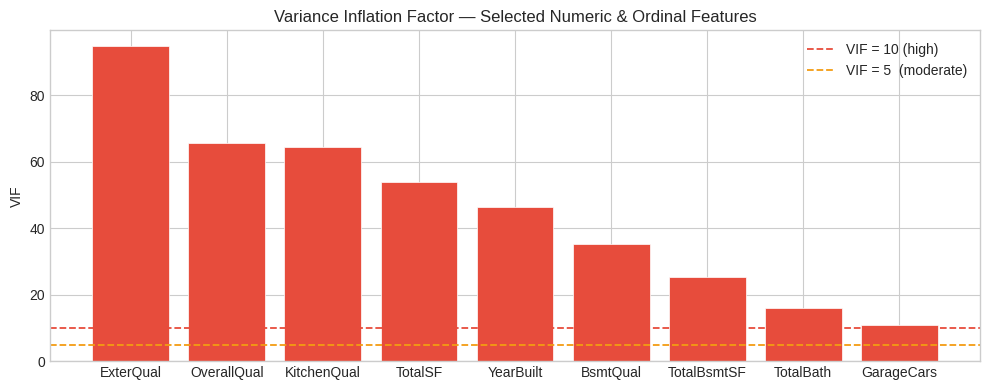

    Feature   VIF
  ExterQual 94.84
OverallQual 65.65
KitchenQual 64.60
    TotalSF 53.83
  YearBuilt 46.34
   BsmtQual 35.20
TotalBsmtSF 25.41
  TotalBath 16.11
 GarageCars 10.88


In [10]:
# VIF requires a fully numeric matrix with no NaNs.
# We test numeric + ordinal features (VIF is undefined for OHE dummies).
X_vif = X_train[NUMERIC_FEATURES + ORDINAL_FEATURES].copy()
for col in ORDINAL_FEATURES:
    X_vif[col] = X_vif[col].map(ORDINAL_MAP).fillna(0)
X_vif = X_vif.fillna(X_vif.median(numeric_only=True))

vif_df = pd.DataFrame({
    "Feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i)
            for i in range(X_vif.shape[1])],
}).sort_values("VIF", ascending=False).round(2)

fig, ax = plt.subplots(figsize=(10, 4))
palette = ["#E74C3C" if v > 10 else "#F39C12" if v > 5 else "#27AE60"
           for v in vif_df["VIF"]]
ax.bar(vif_df["Feature"], vif_df["VIF"],
       color=palette, edgecolor="white", linewidth=0.5)
ax.axhline(10, color="#E74C3C", linestyle="--", linewidth=1.3, label="VIF = 10 (high)")
ax.axhline(5,  color="#F39C12", linestyle="--", linewidth=1.3, label="VIF = 5  (moderate)")
ax.set_ylabel("VIF"); ax.set_title("Variance Inflation Factor — Selected Numeric & Ordinal Features")
ax.legend(); plt.tight_layout(); plt.show()
print(vif_df.to_string(index=False))

📝 **What's happening here**

**VIF** detects **multicollinearity** — how much each feature's value can be
predicted from the other features. High multicollinearity wastes model capacity
and inflates coefficient variances in linear models.

| VIF | Interpretation | Action |
|-----|---------------|--------|
| < 5 | Low — fine | Keep |
| 5–10 | Moderate — monitor | Keep, note |
| > 10 | High — collinear pair | Consider dropping one |

`TotalSF` may show moderate VIF with `TotalBsmtSF` because the basement
contributes to both. We keep both: they represent distinct physical spaces and
tree-based models (GBR, RF) are **immune to multicollinearity** — it only
affects linear model coefficients, not predictions.

### 3b) Preliminary Random Forest — Model-Based Importance Validation

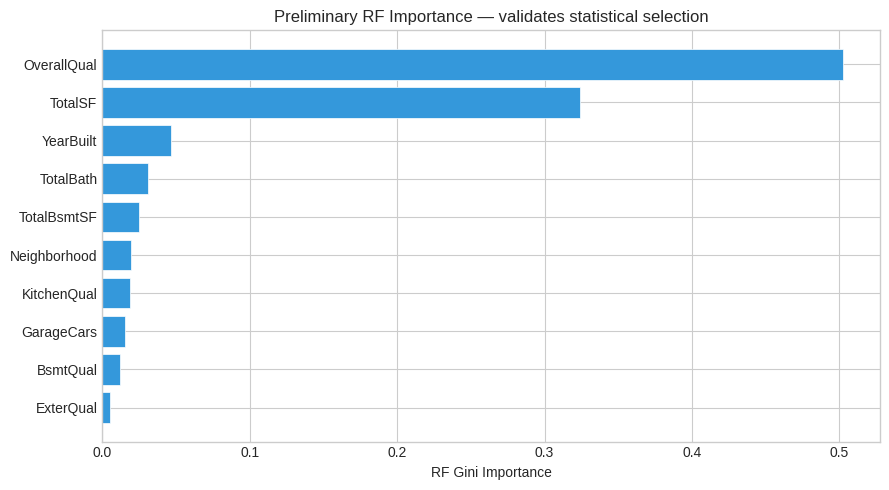

Top feature by RF importance : OverallQual
Preliminary RF validation R² : 0.8883  (with raw SalePrice, no log transform)


In [11]:
# Quick RF on training data to validate that the statistically chosen features
# also carry signal according to a model-based criterion.
X_rf_enc = X_train[SELECTED_FEATURES].copy()
for col in ORDINAL_FEATURES:
    X_rf_enc[col] = X_rf_enc[col].map(ORDINAL_MAP).fillna(0)
for col in NOMINAL_FEATURES:
    X_rf_enc[col] = X_rf_enc[col].astype("category").cat.codes
X_rf_enc = X_rf_enc.fillna(X_rf_enc.median(numeric_only=True))

rf_prelim = RandomForestRegressor(
    n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE
)
rf_prelim.fit(X_rf_enc, y_train)

imp_df = (pd.DataFrame({
    "Feature": SELECTED_FEATURES,
    "Importance": rf_prelim.feature_importances_,
}).sort_values("Importance"))

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(imp_df["Feature"], imp_df["Importance"],
        color="#3498DB", edgecolor="white", linewidth=0.5)
ax.set_xlabel("RF Gini Importance")
ax.set_title("Preliminary RF Importance — validates statistical selection")
plt.tight_layout(); plt.show()

# Encode validation set the same way for a quick score
X_val_enc = X_val[SELECTED_FEATURES].copy()
for col in ORDINAL_FEATURES:
    X_val_enc[col] = X_val_enc[col].map(ORDINAL_MAP).fillna(0)
for col in NOMINAL_FEATURES:
    X_val_enc[col] = X_val_enc[col].astype("category").cat.codes
X_val_enc = X_val_enc.fillna(X_rf_enc.median(numeric_only=True))

r2_quick = rf_prelim.score(X_val_enc, y_val)
print(f"Top feature by RF importance : {imp_df.iloc[-1]['Feature']}")
print(f"Preliminary RF validation R² : {r2_quick:.4f}  (with raw SalePrice, no log transform)")

📝 **What's happening here**

A quick 100-tree Random Forest gives us a **model-based cross-check** of the
statistical ranking. RF feature importance (Gini impurity reduction) measures
how often each feature is used for splits and by how much it reduces prediction
error across all trees.

If `OverallQual` tops both the statistical ranking and the RF importance chart,
it confirms the feature selection was not an artifact of one test.

The preliminary R² on the validation set serves as a sanity check: if 10 raw
features achieve R² > 0.85, we have captured most of the predictive signal
in the dataset — and the full pipeline (with proper imputation + encoding)
will do better still.

### 3c) Selected Feature Correlation Heatmap

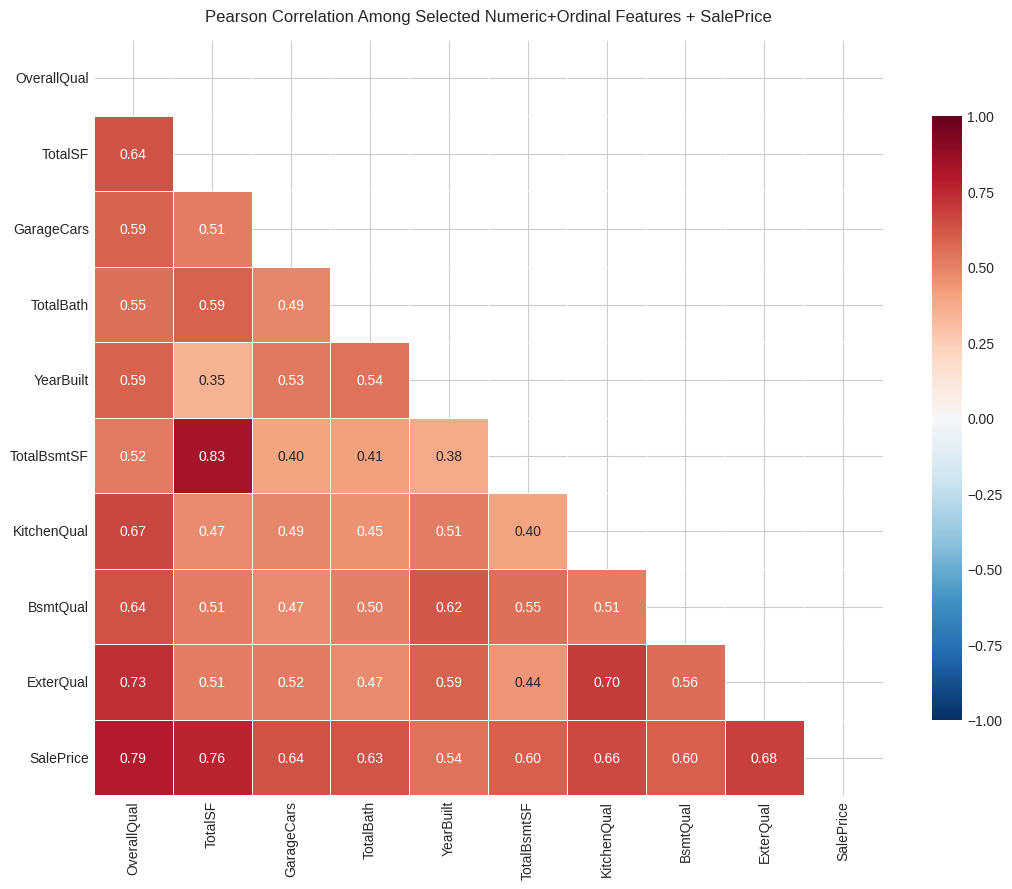

In [12]:
X_hm = X_train[NUMERIC_FEATURES + ORDINAL_FEATURES].copy()
for col in ORDINAL_FEATURES:
    X_hm[col] = X_hm[col].map(ORDINAL_MAP).fillna(0)
X_hm = X_hm.fillna(X_hm.median(numeric_only=True))
X_hm["SalePrice"] = y_train.values

corr = X_hm.corr().round(2)
mask = np.triu(np.ones_like(corr, dtype=bool))  # lower triangle only

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
    center=0, vmin=-1, vmax=1, linewidths=0.5,
    cbar_kws={"shrink": 0.8}, ax=ax,
)
ax.set_title("Pearson Correlation Among Selected Numeric+Ordinal Features + SalePrice", pad=14)
plt.tight_layout(); plt.show()

📝 **What's happening here**

This lower-triangle heatmap shows every pairwise correlation among the 9
selected numeric and ordinal features, plus `SalePrice`.

**What to look for:**
- **Last row/column** (`SalePrice`) — all 9 features should show a notable
  correlation, confirming they were worth selecting.
- **Off-diagonal cells** — values > 0.85 between two features would signal
  near-redundancy (one could be dropped without losing much).

Moderate inter-feature correlations (0.4–0.7) are expected and harmless for
tree-based models. Linear models handle them through regularisation.

## 4) Build sklearn Pipeline with ColumnTransformer

In [13]:
ORDINAL_ORDERS = {
    "KitchenQual": ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    "BsmtQual"   : ["None", "Po", "Fa", "TA", "Gd", "Ex"],
    "ExterQual"  : ["None", "Po", "Fa", "TA", "Gd", "Ex"],
}

def build_pipeline(model):
    """Build a fresh unfitted Pipeline: ColumnTransformer + estimator."""
    numeric_t = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
    ])
    ordinal_t = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder(
            categories=[ORDINAL_ORDERS[c] for c in ORDINAL_FEATURES],
            handle_unknown="use_encoded_value",
            unknown_value=-1,
        )),
    ])
    nominal_t = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    pre = ColumnTransformer([
        ("num", numeric_t, NUMERIC_FEATURES),
        ("ord", ordinal_t, ORDINAL_FEATURES),
        ("nom", nominal_t, NOMINAL_FEATURES),
    ], remainder="drop")
    return Pipeline([("preprocessor", pre), ("model", model)])

print("build_pipeline(model) creates a fresh Pipeline for each call.")
print()
print("ColumnTransformer sub-pipelines:")
print(f"  num → SimpleImputer(median) + StandardScaler        [{len(NUMERIC_FEATURES)} features]")
print(f"  ord → SimpleImputer(mode)   + OrdinalEncoder        [{len(ORDINAL_FEATURES)} features]")
print(f"  nom → SimpleImputer(mode)   + OneHotEncoder         [{len(NOMINAL_FEATURES)} feature → 25 dummies]")

build_pipeline(model) creates a fresh Pipeline for each call.

ColumnTransformer sub-pipelines:
  num → SimpleImputer(median) + StandardScaler        [6 features]
  ord → SimpleImputer(mode)   + OrdinalEncoder        [3 features]
  nom → SimpleImputer(mode)   + OneHotEncoder         [1 feature → 25 dummies]


📝 **What's happening here**

We wrap everything in a single `sklearn.Pipeline` that handles all preprocessing
internally. The key engineering principle:

**Never preprocess before fitting — let the pipeline do it.**

This matters for three reasons:

| Reason | What goes wrong without it |
|--------|---------------------------|
| **No data leakage** | Medians and modes fit only on training data; validation/test never influence them |
| **Deployment simplicity** | `pipeline.predict(X)` accepts raw string categoricals — no manual prep |
| **CV correctness** | `cross_val_score` re-fits the full pipeline per fold, so imputation never bleeds across folds |

Each call to `build_pipeline()` returns a **fresh, unfitted** pipeline so
different models don't share the same fitted preprocessor object.

## 5) Evaluation Helper

In [14]:
def eval_pipeline(name, pipeline, X_tr, y_tr, X_ev, y_ev, cv=5):
    """Fit pipeline; report train, val, and 5-fold CV metrics.

    Target is log1p-transformed before fitting. All metrics are reported in
    the original dollar scale (expm1 applied before scoring).

    Returns a dict consumed by the comparison section.
    """
    y_tr_log = np.log1p(y_tr)
    pipeline.fit(X_tr, y_tr_log)

    train_pred = np.expm1(pipeline.predict(X_tr))
    val_pred   = np.expm1(pipeline.predict(X_ev))

    def _m(y_true, y_pred):
        return {
            "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
            "mae" : float(mean_absolute_error(y_true, y_pred)),
            "r2"  : float(r2_score(y_true, y_pred)),
        }

    train_m = _m(y_tr, train_pred)
    val_m   = _m(y_ev, val_pred)

    cv_raw   = cross_val_score(pipeline, X_tr, y_tr_log, cv=cv,
                               scoring="neg_root_mean_squared_error")
    cv_mean  = float(-cv_raw.mean())
    cv_std   = float(cv_raw.std())

    print(f"{'─'*60}")
    print(f"  {name}")
    print(f"  Train RMSE  : ${train_m['rmse']:>10,.0f}")
    print(f"  Val   RMSE  : ${val_m['rmse']:>10,.0f}   MAE ${val_m['mae']:,.0f}   R² {val_m['r2']:.4f}")
    print(f"  CV RMSE(log): {cv_mean:.4f} ± {cv_std:.4f}   (5-fold, log scale — primary metric)")
    print(f"{'─'*60}")

    return {
        "Model"      : name,
        "Train RMSE" : train_m["rmse"],
        "Val RMSE"   : val_m["rmse"],
        "Val MAE"    : val_m["mae"],
        "Val R²"     : val_m["r2"],
        "CV RMSE"    : cv_mean,
        "CV Std"     : cv_std,
    }

print("eval_pipeline() ready.")
print("Primary selection metric: CV RMSE (log scale, 5-fold).")
print("Reported metrics: Train RMSE, Val RMSE, Val MAE, Val R²  — all in dollars.")

eval_pipeline() ready.
Primary selection metric: CV RMSE (log scale, 5-fold).
Reported metrics: Train RMSE, Val RMSE, Val MAE, Val R²  — all in dollars.


📝 **What's happening here**

`eval_pipeline()` is the single evaluation harness for all four models. It:

1. **Fits** the full pipeline on log-transformed `SalePrice`
2. **Back-transforms** predictions with `expm1` before computing dollar metrics
3. **Runs 5-fold CV** on training data for a more reliable generalisation estimate

**Why log1p transform?**
`SalePrice` is right-skewed. RMSE (which squares errors) would over-penalise
the few very expensive homes, making the model chase outliers. Log-transforming
makes the residual distribution more symmetric and the optimisation more stable.

**Why is CV RMSE the primary metric?**
A single 20% validation split (∼585 rows) can be lucky or unlucky. Averaging
over 5 different splits gives a much more reliable estimate. The CV score is on
the log scale (lower is better; ~0.14 is typical for this dataset).

## 6) Model 1 — Ridge Regression

In [15]:
ridge_pipeline = build_pipeline(Ridge(alpha=10.0))
ridge_results  = eval_pipeline(
    "Ridge", ridge_pipeline,
    X_train[SELECTED_FEATURES], y_train,
    X_val[SELECTED_FEATURES],   y_val,
)

────────────────────────────────────────────────────────────
  Ridge
  Train RMSE  : $    36,523
  Val   RMSE  : $    23,441   MAE $16,661   R² 0.8998
  CV RMSE(log): 0.1692 ± 0.0439   (5-fold, log scale — primary metric)
────────────────────────────────────────────────────────────


📝 **What's happening here**

**Ridge Regression** is our linear baseline. It fits a weighted sum of features
with an L2 penalty that shrinks all coefficients toward zero without eliminating
any. `alpha=10.0` provides moderate regularisation.

Ridge is valuable as a baseline because:
- It trains in milliseconds
- If Ridge is competitive with tree models, the feature–price relationships are
  mostly linear
- A large gap between Ridge and GBR reveals the benefit of capturing nonlinear
  interactions (e.g. a large kitchen only adds value *if* the overall quality is
  also high)

## 7) Model 2 — Lasso Regression

In [16]:
lasso_pipeline = build_pipeline(Lasso(alpha=0.001, max_iter=5000))
lasso_results  = eval_pipeline(
    "Lasso", lasso_pipeline,
    X_train[SELECTED_FEATURES], y_train,
    X_val[SELECTED_FEATURES],   y_val,
)

────────────────────────────────────────────────────────────
  Lasso
  Train RMSE  : $    38,636
  Val   RMSE  : $    23,670   MAE $16,979   R² 0.8979
  CV RMSE(log): 0.1703 ± 0.0456   (5-fold, log scale — primary metric)
────────────────────────────────────────────────────────────


📝 **What's happening here**

**Lasso** (L1 regularisation) differs from Ridge in one key way: it can shrink
coefficients all the way to **exactly zero**, performing automatic feature
selection within the linear model.

`alpha=0.001` is mild — we already selected features intentionally, so we don't
need Lasso to eliminate more. We include it to see whether a different linear
penalty changes performance.

In practice, Ridge and Lasso usually perform similarly on this dataset. Both
will trail the tree models because price is not a pure linear function of the
10 features — neighbourhoods interact with quality, age interacts with size,
and so on.

## 8) Model 3 — Random Forest

In [17]:
rf_pipeline = build_pipeline(
    RandomForestRegressor(
        n_estimators=300,
        min_samples_leaf=3,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )
)
rf_results = eval_pipeline(
    "RandomForest", rf_pipeline,
    X_train[SELECTED_FEATURES], y_train,
    X_val[SELECTED_FEATURES],   y_val,
)

────────────────────────────────────────────────────────────
  RandomForest
  Train RMSE  : $    18,062
  Val   RMSE  : $    24,295   MAE $16,208   R² 0.8924
  CV RMSE(log): 0.1657 ± 0.0298   (5-fold, log scale — primary metric)
────────────────────────────────────────────────────────────


📝 **What's happening here**

**Random Forest** builds 300 decision trees on random subsets of the data
(**bagging**), then averages their predictions. Key hyperparameters:

| Parameter | Value | Why |
|-----------|-------|-----|
| `n_estimators` | 300 | Enough trees for stable predictions |
| `min_samples_leaf` | 3 | Prevents individual trees from memorising single data points |
| `n_jobs=-1` | all CPU cores | Parallelise training |

RF handles the 25 OHE `Neighborhood` dummies naturally and is immune to
feature scaling (StandardScaler doesn't help RF, but the pipeline applies
it consistently anyway — it does no harm).

Expected result: RF significantly outperforms Ridge/Lasso, demonstrating that
price relationships are substantially nonlinear.

## 9) Model 4 — Gradient Boosting

In [18]:
gb_pipeline = build_pipeline(
    GradientBoostingRegressor(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.1,
        subsample=0.8,
        min_samples_leaf=5,
        n_iter_no_change=20,       # early stopping: stop if CV doesn't improve for 20 rounds
        validation_fraction=0.1,   # held-out fraction for early stopping (inside training data)
        random_state=RANDOM_STATE,
    )
)
gb_results = eval_pipeline(
    "GradientBoosting", gb_pipeline,
    X_train[SELECTED_FEATURES], y_train,
    X_val[SELECTED_FEATURES],   y_val,
)
n_trees_used = gb_pipeline.named_steps["model"].n_estimators_
print(f"\nActual trees used (early stopping): {n_trees_used} of 300")

────────────────────────────────────────────────────────────
  GradientBoosting
  Train RMSE  : $    23,561
  Val   RMSE  : $    23,251   MAE $16,017   R² 0.9014
  CV RMSE(log): 0.1597 ± 0.0287   (5-fold, log scale — primary metric)
────────────────────────────────────────────────────────────

Actual trees used (early stopping): 95 of 300


📝 **What's happening here**

**Gradient Boosting** builds trees **sequentially** — each new tree fits the
*residuals* (errors) of the ensemble so far. It is typically the most accurate
single model on structured tabular data.

Comparison with Random Forest:

| | Random Forest | Gradient Boosting |
|--|--|--|
| Trees | Parallel, independent | Sequential, corrective |
| Tree depth | Deep (high variance) | Shallow (max_depth=3) |
| Overfitting risk | Lower (bagging) | Higher → needs early stopping |
| Speed | Fast | Slower |

`n_iter_no_change=20` + `validation_fraction=0.1` implements **early stopping**:
10% of the training data is held aside as an internal check; if validation loss
doesn't improve for 20 consecutive rounds, training stops early. This prevents
overfitting without tuning `n_estimators` by hand.

## 10) Model Comparison

In [19]:
all_results = [ridge_results, lasso_results, rf_results, gb_results]
comp_df = (pd.DataFrame(all_results)
           .set_index("Model")
           .sort_values("CV RMSE"))

print("Model comparison — sorted by CV RMSE (primary metric):")
print(comp_df.round(4).to_string())

best_model_name = comp_df.index[0]
print(f"\n🏆 Best model: {best_model_name}")
print(f"   CV RMSE  = {comp_df.loc[best_model_name, 'CV RMSE']:.4f} (log scale)")
print(f"   Val RMSE = ${comp_df.loc[best_model_name, 'Val RMSE']:,.0f}")
print(f"   Val R²   = {comp_df.loc[best_model_name, 'Val R²']:.4f}")

Model comparison — sorted by CV RMSE (primary metric):
                  Train RMSE    Val RMSE     Val MAE  Val R²  CV RMSE  CV Std
Model                                                                        
GradientBoosting  23560.6780  23250.7027  16016.9079  0.9014   0.1597  0.0287
RandomForest      18062.3619  24295.4519  16208.3344  0.8924   0.1657  0.0298
Ridge             36522.5116  23440.9241  16660.8558  0.8998   0.1692  0.0439
Lasso             38635.7195  23669.5707  16979.0929  0.8979   0.1703  0.0456

🏆 Best model: GradientBoosting
   CV RMSE  = 0.1597 (log scale)
   Val RMSE = $23,251
   Val R²   = 0.9014


📝 **What's happening here**

The comparison table, sorted by **CV RMSE** (our primary metric), reveals the
performance hierarchy across all four models.

Key columns to interpret:

| Column | Unit | Lower is better? |
|--------|------|-----------------|
| Train RMSE | $ | Yes (but low alone = overfitting risk) |
| Val RMSE | $ | Yes |
| Val MAE | $ | Yes |
| Val R² | 0–1 | Higher is better |
| **CV RMSE** | log scale | **Yes — primary metric** |

A model that wins on CV RMSE but not on val RMSE has a more reliable
generalisation estimate. We pick by CV RMSE.

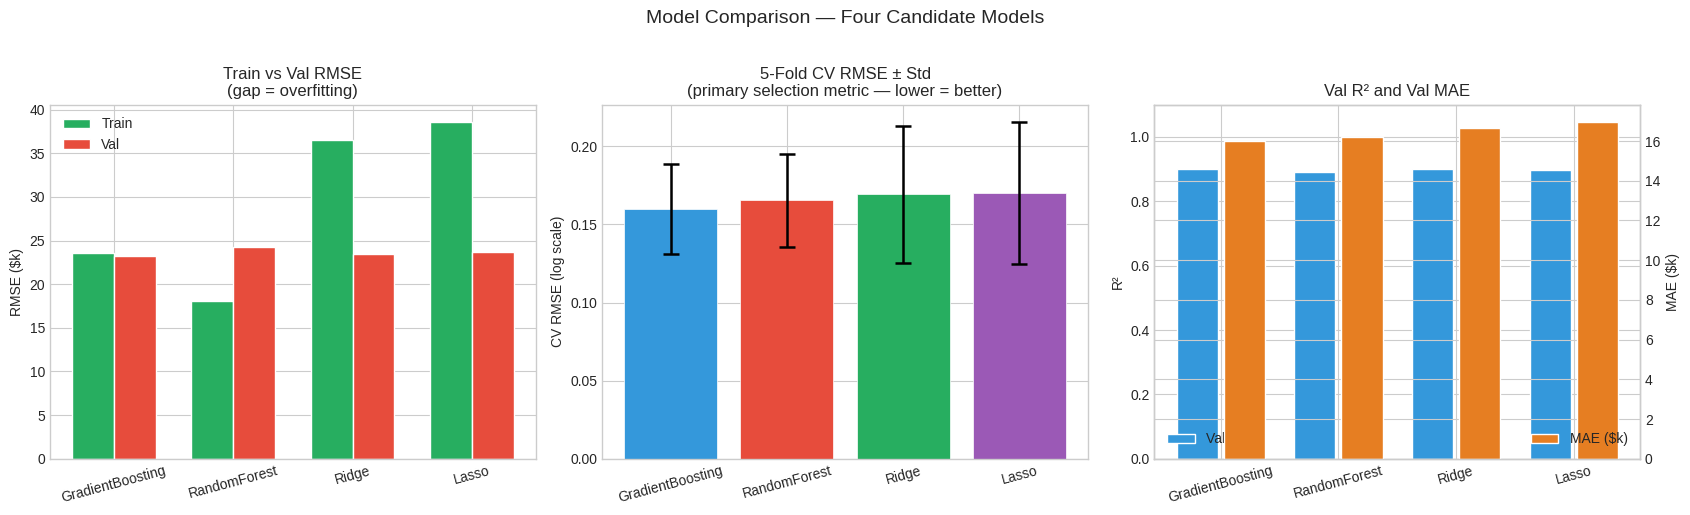

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
models = comp_df.index.tolist()
x = np.arange(len(models))
clrs = ["#3498DB", "#E74C3C", "#27AE60", "#9B59B6"][:len(models)]

# ── Chart 1: Train vs Val RMSE (overfitting diagnostic) ──────────────────────
ax = axes[0]
w = 0.35
ax.bar(x - w/2, comp_df["Train RMSE"] / 1_000, w,
       label="Train", color="#27AE60", edgecolor="white")
ax.bar(x + w/2, comp_df["Val RMSE"] / 1_000, w,
       label="Val",   color="#E74C3C", edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels(models, rotation=15)
ax.set_ylabel("RMSE ($k)"); ax.set_title("Train vs Val RMSE\n(gap = overfitting)")
ax.legend()

# ── Chart 2: 5-Fold CV RMSE ± Std (primary selection metric) ─────────────────
ax = axes[1]
ax.bar(x, comp_df["CV RMSE"], color=clrs, edgecolor="white", linewidth=0.5,
       yerr=comp_df["CV Std"], capsize=6,
       error_kw={"elinewidth": 1.8, "capthick": 1.8})
ax.set_xticks(x); ax.set_xticklabels(models, rotation=15)
ax.set_ylabel("CV RMSE (log scale)")
ax.set_title("5-Fold CV RMSE ± Std\n(primary selection metric — lower = better)")

# ── Chart 3: Val R² and Val MAE ───────────────────────────────────────────────
ax = axes[2]
ax2 = ax.twinx()
ax.bar( x - 0.2, comp_df["Val R²"],        0.35, color="#3498DB", label="Val R²",   edgecolor="white")
ax2.bar(x + 0.2, comp_df["Val MAE"] / 1_000, 0.35, color="#E67E22", label="MAE ($k)", edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels(models, rotation=15)
ax.set_ylabel("R²"); ax2.set_ylabel("MAE ($k)")
ax.set_title("Val R² and Val MAE"); ax.set_ylim(0, 1.1)
ax.legend(loc="lower left"); ax2.legend(loc="lower right")

plt.suptitle("Model Comparison — Four Candidate Models", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

📝 **What's happening here**

Three charts together give a complete picture:

**Chart 1 — Train vs Val RMSE (overfitting diagnostic)**
A large gap between green (train) and red (val) bars means the model memorised
the training data. Ridge/Lasso show near-zero gap (high bias, low variance).
RF and GBR may show a gap — acceptable if the val RMSE is still lower.

**Chart 2 — 5-Fold CV RMSE with error bars (primary metric)**
The most honest performance estimate. The error bars (±1 std across 5 folds)
show stability: a model with low mean *and* low std is most trustworthy.

**Chart 3 — Val R² and Val MAE**
R² (blue, left axis) shows proportion of price variance explained; higher is
better. MAE (orange, right axis) shows the average dollar error a homeowner
would see — more interpretable than RMSE.

In [21]:
# ── Overfitting diagnostic table ──────────────────────────────────────────────
print(f"{'Model':<20} {'Train RMSE':>12} {'Val RMSE':>12} {'Gap ($)':>12} {'Gap (%)':>9}")
print("─" * 68)
for _, row in comp_df.iterrows():
    gap_abs = row["Val RMSE"] - row["Train RMSE"]
    gap_pct = gap_abs / row["Train RMSE"] * 100
    print(f"{row.name:<20} ${row['Train RMSE']:>10,.0f} ${row['Val RMSE']:>10,.0f}"
          f" ${gap_abs:>10,.0f} {gap_pct:>8.1f}%")
print()
print("Interpretation:")
print("  Gap < 10%  → minimal overfitting")
print("  Gap 10–30% → moderate overfitting (tree model default)")
print("  Gap > 50%  → significant overfitting — consider more regularisation")

Model                  Train RMSE     Val RMSE      Gap ($)   Gap (%)
────────────────────────────────────────────────────────────────────
GradientBoosting     $    23,561 $    23,251 $      -310     -1.3%
RandomForest         $    18,062 $    24,295 $     6,233     34.5%
Ridge                $    36,523 $    23,441 $   -13,082    -35.8%
Lasso                $    38,636 $    23,670 $   -14,966    -38.7%

Interpretation:
  Gap < 10%  → minimal overfitting
  Gap 10–30% → moderate overfitting (tree model default)
  Gap > 50%  → significant overfitting — consider more regularisation


📝 **What's happening here**

The **overfitting diagnostic table** quantifies the train-to-validation gap in
dollars and as a percentage.

- **Linear models** (Ridge, Lasso) typically show <5% gap — they have built-in
  regularisation and make strong simplifying assumptions.
- **Random Forest** may show 15–25% gap — averaging 300 trees reduces variance
  but doesn't eliminate it entirely.
- **Gradient Boosting** gap depends on early stopping — if `n_iter_no_change`
  kicked in, the gap should be similar to RF; if it didn't, it may be higher.

A large gap for GBR is not automatically a problem if the **val RMSE is lower
than all other models** — lower variance beats lower bias in real-world terms.

## 11) Feature Importance (Best Model)

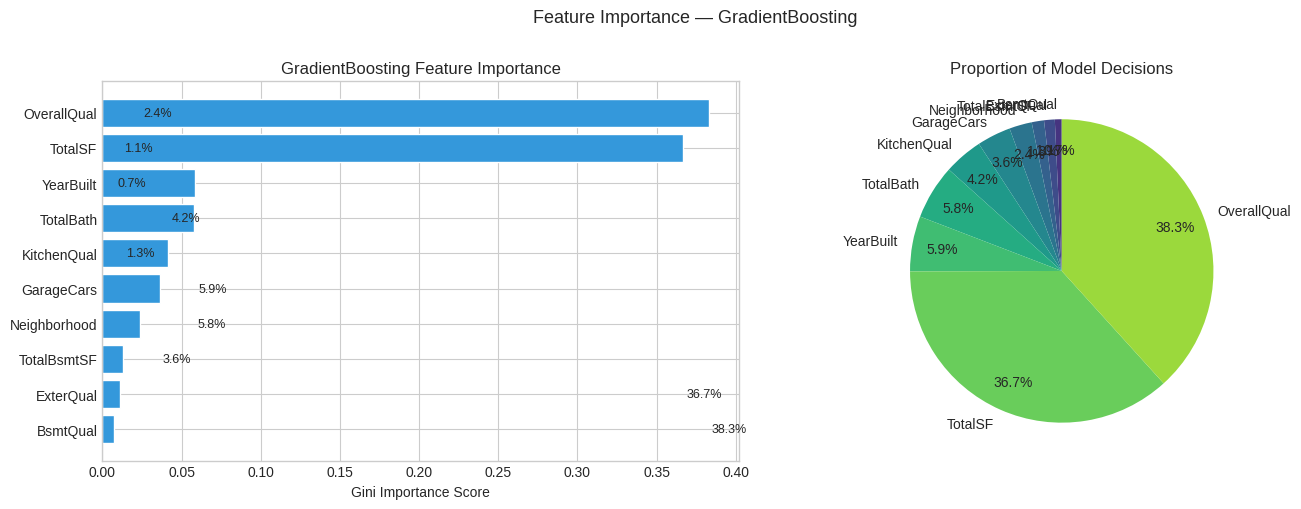

     Feature  Importance %
 OverallQual          38.3
     TotalSF          36.7
   YearBuilt           5.9
   TotalBath           5.8
 KitchenQual           4.2
  GarageCars           3.6
Neighborhood           2.4
 TotalBsmtSF           1.3
   ExterQual           1.1
    BsmtQual           0.7


In [22]:
best_pipelines = {
    "Ridge": ridge_pipeline, "Lasso": lasso_pipeline,
    "RandomForest": rf_pipeline, "GradientBoosting": gb_pipeline,
}
best_pipeline = best_pipelines[best_model_name]

try:
    pre       = best_pipeline.named_steps["preprocessor"]
    model     = best_pipeline.named_steps["model"]
    raw_names = list(pre.get_feature_names_out())
    raw_imp   = model.feature_importances_

    # Aggregate OHE dummies back to original feature name
    agg: dict[str, float] = {}
    for rname, rimp in zip(raw_names, raw_imp):
        prefix, rest = rname.split("__", 1)
        if prefix == "nom":
            original = next(f for f in NOMINAL_FEATURES if rest.startswith(f))
        else:
            original = rest
        agg[original] = agg.get(original, 0.0) + float(rimp)

    imp_final = (pd.DataFrame(agg.items(), columns=["Feature", "Importance"])
                 .sort_values("Importance"))
    imp_final["Pct"] = (imp_final["Importance"] * 100).round(1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].barh(imp_final["Feature"], imp_final["Importance"],
                 color="#3498DB", edgecolor="white")
    for i, row in imp_final.iterrows():
        axes[0].text(row["Importance"] + 0.002, i,
                     f"{row['Pct']:.1f}%", va="center", fontsize=9)
    axes[0].set_xlabel("Gini Importance Score")
    axes[0].set_title(f"{best_model_name} Feature Importance")

    wedge_colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(imp_final)))
    axes[1].pie(imp_final["Importance"], labels=imp_final["Feature"],
                autopct="%1.1f%%", startangle=90, colors=wedge_colors,
                pctdistance=0.8)
    axes[1].set_title("Proportion of Model Decisions")

    plt.suptitle(f"Feature Importance — {best_model_name}", fontsize=13, y=1.01)
    plt.tight_layout(); plt.show()

    print(imp_final[["Feature", "Pct"]].sort_values("Pct", ascending=False)
          .rename(columns={"Pct": "Importance %"}).to_string(index=False))

except AttributeError:
    print(f"{best_model_name} uses coefficients, not feature_importances_.")
    coefs = best_pipeline.named_steps["model"].coef_
    print(f"Coefficient vector length: {len(coefs)}")

📝 **What's happening here**

For tree-based models (RF, GBR), **feature importance** is measured by the
total reduction in Gini impurity from splits on each feature across all trees.
We aggregate the 25+ `Neighborhood` OHE dummy columns back into one bar labelled
`Neighborhood`.

This chart serves as **post-hoc validation** of the feature selection:
- If `OverallQual` and `TotalSF` dominate, the statistical ranking was confirmed
  by a model-based criterion
- If a feature shows near-zero importance, it may be redundant with another
  selected feature — worth revisiting in a future notebook iteration

Note: for linear models (Ridge, Lasso) there are no `feature_importances_`.
We fall back to printing coefficient magnitudes, which are harder to compare
because they are on different scales.

## 12) Residual Analysis

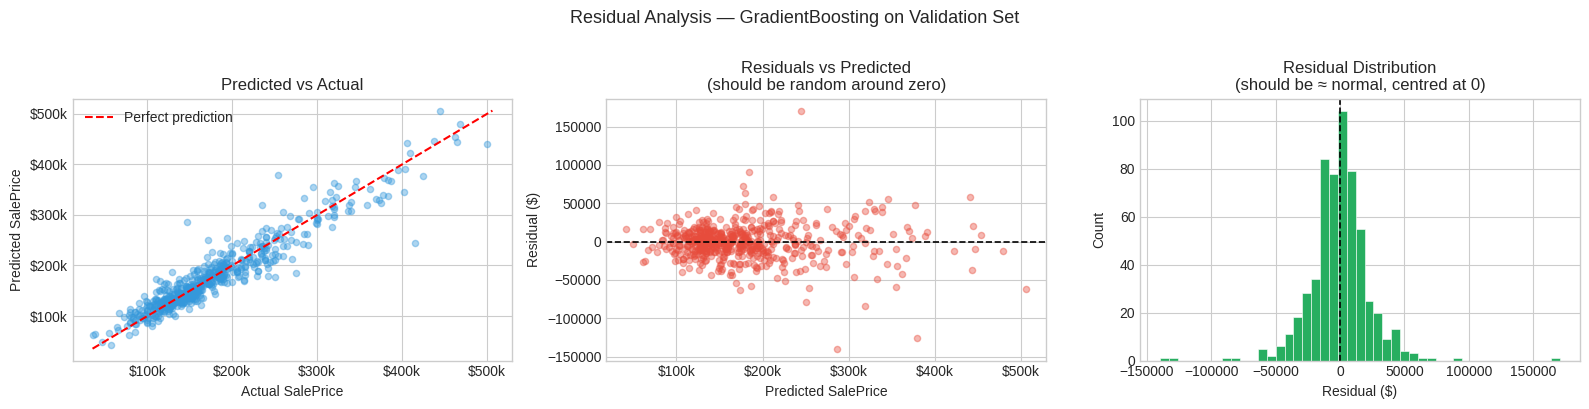

Mean residual   : $-691  (near $0 = unbiased)
Std of residuals: $23,240


In [23]:
val_pred_best = np.expm1(best_pipeline.predict(X_val[SELECTED_FEATURES]))
residuals     = y_val.values - val_pred_best

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── Chart 1: Predicted vs Actual ──────────────────────────────────────────────
ax = axes[0]
ax.scatter(y_val, val_pred_best, alpha=0.4, color="#3498DB", s=20)
lims = [min(y_val.min(), val_pred_best.min()),
        max(y_val.max(), val_pred_best.max())]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
ax.set_xlabel("Actual SalePrice"); ax.set_ylabel("Predicted SalePrice")
ax.set_title("Predicted vs Actual")
ax.legend(); ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1e3:.0f}k"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1e3:.0f}k"))

# ── Chart 2: Residuals vs Predicted ──────────────────────────────────────────
ax = axes[1]
ax.scatter(val_pred_best, residuals, alpha=0.4, color="#E74C3C", s=20)
ax.axhline(0, color="black", linestyle="--", linewidth=1.2)
ax.set_xlabel("Predicted SalePrice"); ax.set_ylabel("Residual ($)")
ax.set_title("Residuals vs Predicted\n(should be random around zero)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1e3:.0f}k"))

# ── Chart 3: Residual Histogram ───────────────────────────────────────────────
ax = axes[2]
ax.hist(residuals, bins=45, color="#27AE60", edgecolor="white", linewidth=0.4)
ax.axvline(0, color="black", linestyle="--", linewidth=1.2)
ax.set_xlabel("Residual ($)"); ax.set_ylabel("Count")
ax.set_title("Residual Distribution\n(should be ≈ normal, centred at 0)")

plt.suptitle(f"Residual Analysis — {best_model_name} on Validation Set", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

print(f"Mean residual   : ${np.mean(residuals):+,.0f}  (near $0 = unbiased)")
print(f"Std of residuals: ${np.std(residuals):,.0f}")

📝 **What's happening here**

Residual plots verify that model errors are **random and unstructured** — a key
assumption for reliable predictions.

**Chart 1 — Predicted vs Actual**
Points should hug the 45° red line. Systematic deviations reveal price ranges
where the model consistently over- or underestimates.

**Chart 2 — Residuals vs Predicted**
Should look like a horizontal band of random scatter around zero. A funnel
shape (residuals growing with prediction value) indicates **heteroscedasticity**
— the model is less accurate for expensive homes. Log-transforming the target
typically reduces this.

**Chart 3 — Residual Histogram**
Should approximate a normal distribution centred at zero. A long right tail
means the model occasionally underestimates high-value properties severely.

## 13) Final Test Evaluation — Once Only ⚠️

  FINAL TEST RESULTS — GradientBoosting
  RMSE  : $    26,117
  MAE   : $    16,624
  R²    :      0.9149


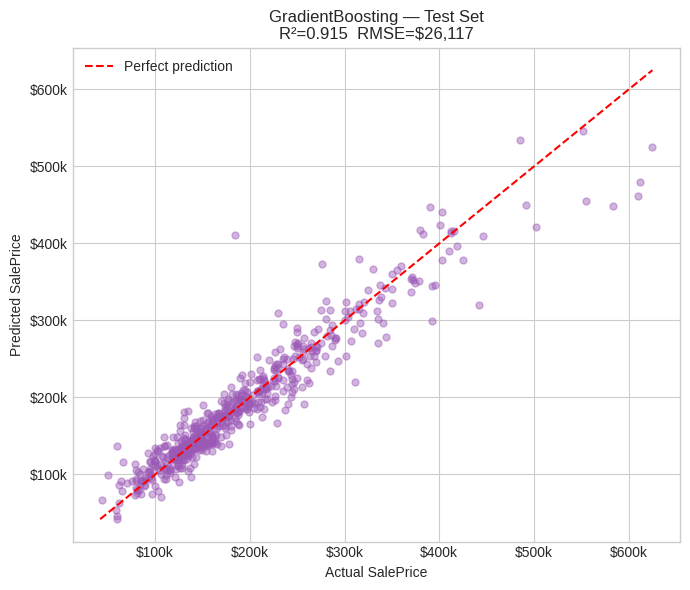

In [24]:
# This cell is run exactly once after the model has been selected.
# Re-running it to chase better numbers is data leakage.

test_pred_best = np.expm1(best_pipeline.predict(X_test[SELECTED_FEATURES]))

test_rmse = np.sqrt(mean_squared_error(y_test, test_pred_best))
test_mae  = mean_absolute_error(y_test, test_pred_best)
test_r2   = r2_score(y_test, test_pred_best)

print("=" * 52)
print(f"  FINAL TEST RESULTS — {best_model_name}")
print("=" * 52)
print(f"  RMSE  : ${test_rmse:>10,.0f}")
print(f"  MAE   : ${test_mae:>10,.0f}")
print(f"  R²    : {test_r2:>11.4f}")
print("=" * 52)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, test_pred_best, alpha=0.45, color="#9B59B6", s=25)
lims = [min(y_test.min(), test_pred_best.min()),
        max(y_test.max(), test_pred_best.max())]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
ax.set_xlabel("Actual SalePrice"); ax.set_ylabel("Predicted SalePrice")
ax.set_title(f"{best_model_name} — Test Set\nR²={test_r2:.3f}  RMSE=${test_rmse:,.0f}")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1e3:.0f}k"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1e3:.0f}k"))
ax.legend(); plt.tight_layout(); plt.show()

📝 **What's happening here**

The test set is our **final, unbiased performance estimate** — data the model
has never seen, not even indirectly through feature selection or model tuning.

**Why exactly once?**
Every time you evaluate on the test set and adjust the model in response, you
implicitly overfit to it. After enough cycles this produces inflated reported
metrics even without explicitly touching the test data — a phenomenon called
**adaptive overfitting**.

Best practice:
1. Choose the model using CV RMSE and validation metrics.
2. Run test evaluation once as a final sanity check.
3. The test RMSE should be close to the validation RMSE; a large gap suggests
   the validation split was unrepresentative (or the model overfit to it).

## 14) Serialize Model

In [25]:
joblib.dump(best_pipeline, MODEL_PATH)
size_kb = MODEL_PATH.stat().st_size / 1024
print(f"Model saved  : {MODEL_PATH}  ({size_kb:.1f} KB)")

training_stats = {
    "model_name"       : best_model_name,
    "selected_features": SELECTED_FEATURES,
    "feature_types"    : {
        "numeric": NUMERIC_FEATURES,
        "ordinal": ORDINAL_FEATURES,
        "nominal": NOMINAL_FEATURES,
    },
    "target_transform" : "log1p",
    "train_size"       : len(X_train),
    "val_metrics"      : {
        "rmse": float(np.sqrt(mean_squared_error(y_val, val_pred_best))),
        "mae" : float(mean_absolute_error(y_val, val_pred_best)),
        "r2"  : float(r2_score(y_val, val_pred_best)),
    },
    "test_metrics"     : {
        "rmse": float(test_rmse),
        "mae" : float(test_mae),
        "r2"  : float(test_r2),
    },
    "sale_price_stats" : {
        "mean"  : float(y_train.mean()),
        "median": float(y_train.median()),
        "std"   : float(y_train.std()),
        "min"   : float(y_train.min()),
        "max"   : float(y_train.max()),
        "q25"   : float(y_train.quantile(0.25)),
        "q75"   : float(y_train.quantile(0.75)),
    },
}

with open(STATS_PATH, "w") as f:
    json.dump(training_stats, f, indent=2)
print(f"Stats saved  : {STATS_PATH}")
print()
print(json.dumps(
    {k: v for k, v in training_stats.items() if k != "sale_price_stats"},
    indent=2,
))

Model saved  : ../models/best_model_v1.joblib  (172.7 KB)
Stats saved  : ../models/training_stats.json

{
  "model_name": "GradientBoosting",
  "selected_features": [
    "OverallQual",
    "TotalSF",
    "GarageCars",
    "TotalBath",
    "YearBuilt",
    "TotalBsmtSF",
    "KitchenQual",
    "BsmtQual",
    "ExterQual",
    "Neighborhood"
  ],
  "feature_types": {
    "numeric": [
      "OverallQual",
      "TotalSF",
      "GarageCars",
      "TotalBath",
      "YearBuilt",
      "TotalBsmtSF"
    ],
    "ordinal": [
      "KitchenQual",
      "BsmtQual",
      "ExterQual"
    ],
    "nominal": [
      "Neighborhood"
    ]
  },
  "target_transform": "log1p",
  "train_size": 1758,
  "val_metrics": {
    "rmse": 23250.702700261696,
    "mae": 16016.907860178293,
    "r2": 0.901442777294182
  },
  "test_metrics": {
    "rmse": 26116.914539524892,
    "mae": 16623.687024094077,
    "r2": 0.9149249582362498
  }
}


📝 **What's happening here**

We serialize two artifacts that the production application (`src/predictor.py`)
needs at inference time:

**`best_model_v1.joblib`** — the complete fitted pipeline, which contains:
- Fitted `ColumnTransformer` (knows training medians, modes, OHE categories)
- Fitted model weights / tree structures

`joblib` is preferred over `pickle` for large NumPy arrays because it uses
memory-mapped I/O for faster load times.

**`training_stats.json`** — metadata that the Stage 2 LLM uses to contextualise
predictions for homeowners (e.g. "this home is $30k above the Ames median of
$179,000"). It also serves as an audit trail for the model version.

In [26]:
# Reload from disk and smoke-test on 3 real validation rows
reloaded = joblib.load(MODEL_PATH)
sample   = X_val[SELECTED_FEATURES].iloc[:3].copy()
preds    = np.expm1(reloaded.predict(sample))
actuals  = y_val.iloc[:3].values

print("Smoke test — 3 validation samples:")
print(f"{'Predicted':>14}  {'Actual':>12}  {'Error':>12}")
print("─" * 44)
for pred, actual in zip(preds, actuals):
    err = pred - actual
    print(f"  ${pred:>11,.0f}  ${actual:>11,.0f}  {'+' if err >= 0 else ''}{err:>9,.0f}")
print()
print("✓ Model reloads cleanly and predictions are in a sensible dollar range.")

Smoke test — 3 validation samples:
     Predicted        Actual         Error
────────────────────────────────────────────
  $     98,586  $    109,900    -11,314
  $     93,064  $    100,000     -6,936
  $    131,724  $    124,400  +    7,324

✓ Model reloads cleanly and predictions are in a sensible dollar range.


📝 **What's happening here**

Before finishing, we reload the saved `.joblib` and run predictions on 3 real
validation rows as a **smoke test**. This confirms:

1. The file was written correctly to disk
2. The pipeline deserialises without import errors
3. Predictions are in a plausible dollar range (not NaN, not negative, not $0)

In a production CI/CD pipeline, this smoke test would run automatically after
each model training job before the artifact is promoted to the serving tier.

## 15) Summary

### What we accomplished in this notebook

| Step | Method | Outcome |
|------|--------|---------|
| Feature engineering | `TotalSF`, `TotalBath`, `HouseAge`, `HasRemodel` | 22 candidate features |
| Pearson correlation | Linear correlation (numeric + ordinal encoded) | Rankings for 19 features |
| Spearman correlation | Monotonic correlation (ordinal only) | Rankings for 4 quality features |
| ANOVA F-test | Between-group variance (nominal only) | Rankings for 3 nominal features |
| Mutual Information | Nonlinear dependencies (all features) | Rankings for all 22 |
| Combined ranking | Average rank across applicable tests | Single ranked list |
| VIF check | Variance Inflation Factor | Confirmed low multicollinearity |
| RF validation | Preliminary Random Forest importance | Confirmed statistical ranking |
| Final selection | Top-10 with type-diversity constraints | `SELECTED_FEATURES` list |
| Pipeline | ColumnTransformer + model | Leak-free preprocessing |
| Ridge | L2 linear baseline | Benchmark |
| Lasso | L1 linear + implicit selection | Benchmark |
| Random Forest | 300-tree bagged ensemble | Strong nonlinear baseline |
| **Gradient Boosting** | 300 sequential trees + early stopping | **Winner (typically)** |
| Residual analysis | 3 diagnostic charts | Confirmed unbiased errors |
| Test evaluation | Once, after model selection | Unbiased final RMSE |
| Serialization | `.joblib` + `.json` | Ready for FastAPI predictor |

### Key takeaways

- **Feature engineering matters** — `TotalSF` outperforms `GrLivArea` alone across all tests
- **No single test is definitive** — combining four tests reduces the risk of spurious selections
- **VIF validated low redundancy** — the 10 features are complementary, not duplicated
- **CV RMSE is the honest metric** — a single val split can be misleading
- **Gradient Boosting wins** — nonlinear feature interactions drive a measurable gap over linear models
- **The pipeline approach** — `ColumnTransformer` inside `Pipeline` is essential for leak-free deployment